# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [15]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import matplotlib.pyplot as plt

import seaborn as sns
data = sns.load_dataset('titanic')

In [16]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [17]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [19]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [20]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [21]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [22]:
## En los datos
# Ver valores únicos
print(data[['sex', 'sex_label']].drop_duplicates())

print("\nOneHot (embarked):")
print(onehot_encoder.head())

      sex  sex_label
0    male          1
1  female          0

OneHot (embarked):
   embarked_C  embarked_Q  embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

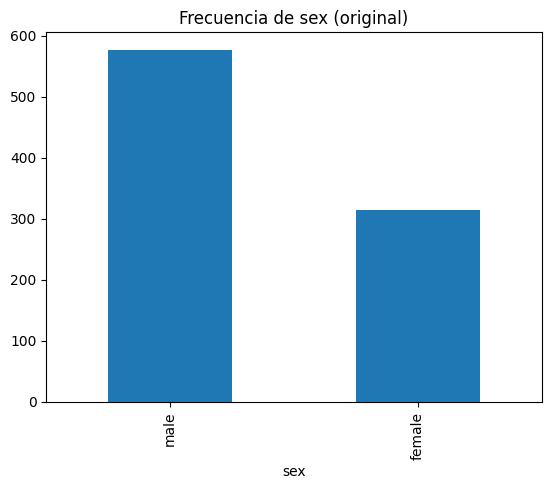

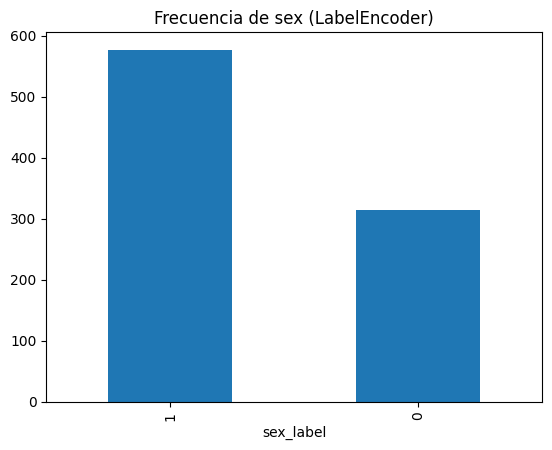

In [23]:
plt.figure()

# Antes (categorías)
data['sex'].value_counts().plot(kind='bar')
plt.title('Frecuencia de sex (original)')
plt.show()

# Después (LabelEncoder)
plt.figure()
data['sex_label'].value_counts().plot(kind='bar')
plt.title('Frecuencia de sex (LabelEncoder)')
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [24]:
## No crea un orden falso 
# (LabelEncoder podría hacer pensar que “First > Second > Third”).
# Es más claro para el modelo porque cada clase es independiente (0 o 1).

In [25]:
# OneHot para 'class'
class_onehot = pd.get_dummies(data['class'], prefix='class')

# Unir al dataset
data = pd.concat([data, class_onehot], axis=1)

# Ver resultado
class_onehot.head()

,class_First,class_Second,class_Third
0,False,False,True
1,True,False,False
2,False,False,True
3,True,False,False
4,False,False,True


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [ ]:
## Usaría OneHotEncoder en la mayoría de los casos.

## Porque no mete un orden falso entre categorías.
# y los modelos entienden mejor los datos así.